<a href="https://colab.research.google.com/github/Sayani-svg/speech-recognition/blob/main/Audio_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))


GPU available: []


In [ ]:
!pip install -q librosa jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.5 MB/s eta 0:00:00


In [ ]:
import librosa, jiwer, tensorflow as tf
print("TF version:", tf.__version__)
print("Librosa version:", librosa.__version__)

TF version: 2.20.0
Librosa version: 0.11.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf LJSpeech-1.1 LJSpeech-1.1.tar.bz2
!wget -q https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2
!tar -xjf LJSpeech-1.1.tar.bz2

In [ ]:
import pandas as pd

df = pd.read_csv(
    'LJSpeech-1.1/metadata.csv',
    sep='|', header=None,
    names=['file_id', 'original', 'normalized'],
    quoting=3  # avoids issues with quote characters in transcripts
)

print(f"Total samples: {len(df)}")
print(df.head())
print(f"\nShortest transcript: {df['normalized'].str.len().min()} chars")
print(f"Longest transcript: {df['normalized'].str.len().max()} chars")

Total samples: 13100
      file_id                                           original  \
0  LJ001-0001  Printing, in the only sense with which we are ...   
1  LJ001-0002                     in being comparatively modern.   
2  LJ001-0003  For although the Chinese took impressions from...   
3  LJ001-0004  produced the block books, which were the immed...   
4  LJ001-0005  the invention of movable metal letters in the ...   

                                          normalized  
0  Printing, in the only sense with which we are ...  
1                     in being comparatively modern.  
2  For although the Chinese took impressions from...  
3  produced the block books, which were the immed...  
4  the invention of movable metal letters in the ...  

Shortest transcript: 12 chars
Longest transcript: 187 chars


In [ ]:
import numpy as np

# Define the character vocabulary
# Includes lowercase letters, space, apostrophe, and a blank token for CTC
characters = [c for c in "abcdefghijklmnopqrstuvwxyz' "]

char_to_num = {char: idx for idx, char in enumerate(characters)}
num_to_char = {idx: char for idx, char in enumerate(characters)}

vocab_size = len(characters)
print(f"Vocabulary size: {vocab_size}")
print(char_to_num)

Vocabulary size: 28
{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25, "'": 26, ' ': 27}


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z' ]", "", text)  # remove punctuation, numbers, etc.
    text = re.sub(r"\s+", " ", text).strip()
    return text

def encode_text(text):
    text = clean_text(text)
    return [char_to_num[c] for c in text if c in char_to_num]

# Quick test
sample = df['normalized'].iloc[0]
print("Original:", sample)
print("Cleaned:", clean_text(sample))
print("Encoded:", encode_text(sample))

Original: Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition
Cleaned: printing in the only sense with which we are at present concerned differs from most if not from all the arts and crafts represented in the exhibition
Encoded: [15, 17, 8, 13, 19, 8, 13, 6, 27, 8, 13, 27, 19, 7, 4, 27, 14, 13, 11, 24, 27, 18, 4, 13, 18, 4, 27, 22, 8, 19, 7, 27, 22, 7, 8, 2, 7, 27, 22, 4, 27, 0, 17, 4, 27, 0, 19, 27, 15, 17, 4, 18, 4, 13, 19, 27, 2, 14, 13, 2, 4, 17, 13, 4, 3, 27, 3, 8, 5, 5, 4, 17, 18, 27, 5, 17, 14, 12, 27, 12, 14, 18, 19, 27, 8, 5, 27, 13, 14, 19, 27, 5, 17, 14, 12, 27, 0, 11, 11, 27, 19, 7, 4, 27, 0, 17, 19, 18, 27, 0, 13, 3, 27, 2, 17, 0, 5, 19, 18, 27, 17, 4, 15, 17, 4, 18, 4, 13, 19, 4, 3, 27, 8, 13, 27, 19, 7, 4, 27, 4, 23, 7, 8, 1, 8, 19, 8, 14, 13]


In [ ]:
import librosa

SAMPLE_RATE = 16000
N_MELS = 80
HOP_LENGTH = 160      # 10ms at 16kHz
WIN_LENGTH = 400       # 25ms at 16kHz
N_FFT = 512

def audio_to_spectrogram(file_path):
    # Load audio, resample to 16kHz
    audio, _ = librosa.load(file_path, sr=SAMPLE_RATE)

    # Compute mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmax=8000
    )

    # Convert power spectrogram to log scale (dB)
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)

    # Normalize (zero mean, unit variance) — helps training stability
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-8)

    # Transpose so shape is (Time, Mel_bins) instead of (Mel_bins, Time)
    return log_mel.T.astype(np.float32)

Spectrogram shape: (966, 80)


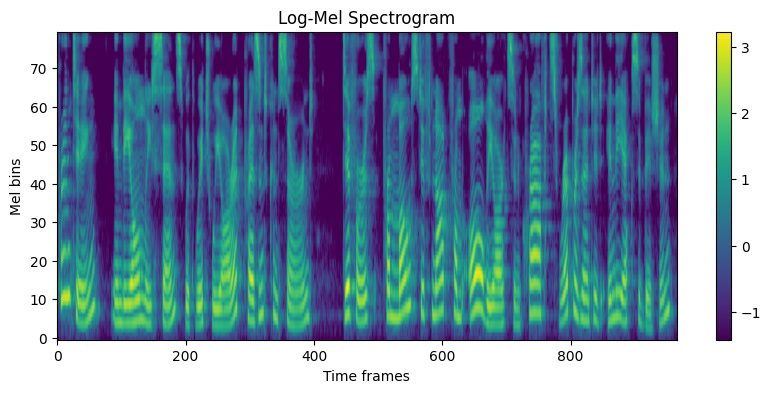

In [ ]:
test_path = 'LJSpeech-1.1/wavs/' + df['file_id'].iloc[0] + '.wav'
spec = audio_to_spectrogram(test_path)
print("Spectrogram shape:", spec.shape)  # (Time, 80)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.imshow(spec.T, aspect='auto', origin='lower', cmap='viridis')
plt.title("Log-Mel Spectrogram")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.colorbar()
plt.savefig("sample_spectrogram.png")
plt.show()

In [ ]:
import tensorflow as tf

# Train/Val/Test split (80/10/10)
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

WAVS_PATH = 'LJSpeech-1.1/wavs/'

def load_sample(file_id, text):
    file_id = file_id.numpy().decode('utf-8')
    text = text.numpy().decode('utf-8')

    audio_path = WAVS_PATH + file_id + '.wav'
    spectrogram = audio_to_spectrogram(audio_path)        # (Time, 80)
    label = np.array(encode_text(text), dtype=np.int32)   # (Label_len,)

    return spectrogram, label

def tf_load_sample(file_id, text):
    spectrogram, label = tf.py_function(
        func=load_sample,
        inp=[file_id, text],
        Tout=[tf.float32, tf.int32]
    )
    spectrogram.set_shape([None, N_MELS])
    label.set_shape([None])
    return spectrogram, label

def make_dataset(dataframe, batch_size=8, shuffle=True):
    file_ids = dataframe['file_id'].values
    texts = dataframe['normalized'].values

    ds = tf.data.Dataset.from_tensor_slices((file_ids, texts))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))

    ds = ds.map(tf_load_sample, num_parallel_calls=tf.data.AUTOTUNE)

    # Pad spectrograms with 0.0, labels with -1 (so we can distinguish padding from real char index 0)
    ds = ds.padded_batch(
        batch_size,
        padding_values=(tf.constant(0.0, dtype=tf.float32),
                         tf.constant(-1, dtype=tf.int32)),
        padded_shapes=([None, N_MELS], [None])
    )

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, batch_size=8, shuffle=True)
val_ds   = make_dataset(val_df, batch_size=8, shuffle=False)
test_ds  = make_dataset(test_df, batch_size=8, shuffle=False)

Train: 10480, Val: 1310, Test: 1310


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_model(n_mels=80, vocab_size=28, lstm_units=256):
    """
    n_mels: number of mel frequency bins (input feature dimension)
    vocab_size: number of characters in vocabulary (without CTC blank)
    lstm_units: hidden units per LSTM layer
    """

    # ── Input ──────────────────────────────────────────
    # Shape: (batch, time, n_mels) -> we add channel dim for Conv2D
    inputs = layers.Input(shape=(None, n_mels), name="spectrogram")
    x = layers.Reshape((-1, n_mels, 1))(inputs)   # (batch, time, n_mels, 1)

    # ── CNN Block ──────────────────────────────────────
    x = layers.Conv2D(32, kernel_size=(3, 3), padding="same",
                       use_bias=False, name="conv_1")(x)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.ReLU(name="relu_1")(x)
    x = layers.MaxPooling2D(pool_size=(1, 2), name="pool_1")(x)
    # Pooling only on frequency axis (1,2) — NOT on time axis
    # We must preserve time resolution since each time-step becomes one CTC frame

    x = layers.Conv2D(64, kernel_size=(3, 3), padding="same",
                       use_bias=False, name="conv_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.ReLU(name="relu_2")(x)
    x = layers.MaxPooling2D(pool_size=(1, 2), name="pool_2")(x)

    # ── Reshape for LSTM ───────────────────────────────
    # After 2x (1,2) pooling, frequency dim = n_mels // 4
    freq_dim = (n_mels // 2) // 2
    x = layers.Reshape((-1, freq_dim * 64), name="reshape_to_sequence")(x)

    # ── LSTM Block (unidirectional — real-time capable) ─
    x = layers.LSTM(lstm_units, return_sequences=True, name="lstm_1")(x)
    x = layers.Dropout(0.3, name="dropout_1")(x)
    x = layers.LSTM(lstm_units, return_sequences=True, name="lstm_2")(x)
    lstm_out = layers.Dropout(0.3, name="dropout_2")(x)

    # ── Attention Layer ────────────────────────────────
    # Score each time-step's relevance
    attention_scores = layers.Dense(1, activation="tanh", name="attn_score")(lstm_out)
    attention_weights = layers.Softmax(axis=1, name="attn_weights")(attention_scores)
    # Element-wise reweighting of LSTM output by attention (NOT collapsing to single vector,
    # since we need per-timestep output for CTC, not a single summary vector)
    context = layers.Multiply(name="attn_context")([lstm_out, attention_weights])
    x = layers.Add(name="attn_residual")([lstm_out, context])
    # Residual connection: keeps original signal + attention-weighted emphasis

    # ── Output Layer ───────────────────────────────────
    # vocab_size + 1 because CTC needs one extra "blank" label
    outputs = layers.Dense(vocab_size + 1, activation="softmax", name="output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="CNN_LSTM_Attention_ASR")
    return model


model = build_model(n_mels=N_MELS, vocab_size=vocab_size)
model.summary()

Model: "CNN_LSTM_Attention_ASR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spectrogram         │ (None, None, 80)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, None, 80,  │          0 │ spectrogram[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, None, 80,  │        288 │ reshape[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, None, 80,  │        128 │ conv_1[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (ReLU)       │ (None, None, 80,  │          0 │ bn_1[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_1              │ (None, None, 40,  │          0 │ relu_1[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv2D)     │ (None, None, 40,  │     18,432 │ pool_1[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, None, 40,  │        256 │ conv_2[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (ReLU)       │ (None, None, 40,  │          0 │ bn_2[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2              │ (None, None, 20,  │          0 │ relu_2[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_to_sequence │ (None, None,      │          0 │ pool_2[0][0]      │
│ (Reshape)           │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 256) │  1,573,888 │ reshape_to_seque… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, None, 256) │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, None, 256) │    525,312 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, None, 256) │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_score (Dense)  │ (None, None, 1)   │        257 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_weights        │ (None, None, 1)   │          0 │ attn_score[0][0]  │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_context        │ (None, None, 256) │          0 │ dropout_2[0][0],  │
│ (Multiply)          │                   │            │ attn_weights[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,126,014 (8.11 MB)

 Trainable params: 2,125,822 (8.11 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
def ctc_loss_fn(y_true, y_pred):
    """
    y_true: (batch, max_label_len) — padded with -1
    y_pred: (batch, max_time, vocab_size + 1) — softmax outputs
    """
    batch_len = tf.shape(y_pred)[0]
    time_steps = tf.shape(y_pred)[1]
    input_length = tf.ones(shape=(batch_len,), dtype=tf.int32) * time_steps

    label_mask = tf.cast(tf.not_equal(y_true, -1), tf.int32)
    label_length = tf.reduce_sum(label_mask, axis=1)

    y_true_clean = tf.where(tf.equal(y_true, -1), tf.zeros_like(y_true), y_true)

    loss = tf.keras.backend.ctc_batch_cost(
        y_true_clean,
        y_pred,
        tf.expand_dims(input_length, axis=1),
        tf.expand_dims(label_length, axis=1)
    )

    return tf.reduce_mean(loss)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss=ctc_loss_fn)

In [ ]:
for spec_batch, label_batch in train_ds.take(1):
    preds = model(spec_batch, training=False)
    loss_value = ctc_loss_fn(label_batch, preds)
    print("Sample CTC loss:", loss_value.numpy())

Sample CTC loss: 2452.04


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/asr_checkpoints', exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/content/drive/MyDrive/asr_checkpoints/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        '/content/drive/MyDrive/asr_checkpoints/training_log.csv'
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - loss: 270.8250
Epoch 1: val_loss improved from None to 114.17186, saving model to /content/drive/MyDrive/asr_checkpoints/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/asr_checkpoints/best_model.keras
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 716s 540ms/step - loss: 201.7546 - val_loss: 114.1719 - learning_rate: 0.0010
Epoch 2/50
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - loss: 103.1825
Epoch 2: val_loss improved from 114.17186 to 72.57861, saving model to /content/drive/MyDrive/asr_checkpoints/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/asr_checkpoints/best_model.keras
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 682s 497ms/step - loss: 94.4016 - val_loss: 72.5786 - learning_rate: 0.0010
Epoch 3/50
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - loss: 74.0839
Epoch 3: val_loss improved from 72.57861 to 57.65376, saving model to /content/drive/MyDrive/asr_checkpoints/best_model.keras

Epoch 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.path.exists('/content/drive/MyDrive/asr_checkpoints/best_model.keras'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True


In [ ]:
import pandas as pd
log = pd.read_csv('/content/drive/MyDrive/asr_checkpoints/training_log.csv')
print(log)

    epoch  learning_rate        loss    val_loss
0       0          0.001  201.754608  114.171860
1       1          0.001   94.401642   72.578606
2       2          0.001   70.610199   57.653759
3       3          0.001   57.923969   49.447075
4       4          0.001   49.992493   44.672939
5       5          0.001   44.254337   40.840862
6       6          0.001   39.963726   37.600719
7       7          0.001   36.375443   35.172474
8       8          0.001   33.641964   33.913090
9       9          0.001   31.104849   33.253265
10     10          0.001   29.308550   31.351097
11     11          0.001   27.720217   30.472332
12     12          0.001   26.101551   29.671413
13     13          0.001   24.757700   28.799391


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
print(os.path.exists('/content/drive/MyDrive/asr_checkpoints/best_model.keras'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True


In [ ]:
print('df' in dir())
print('encode_text' in dir())
print('audio_to_spectrogram' in dir())
print('ctc_loss_fn' in dir())

True
True
True
True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/asr_checkpoints/best_model.keras',
    custom_objects={'ctc_loss_fn': ctc_loss_fn}
)
print("Model loaded successfully")
model.summary()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded successfully


Model: "CNN_LSTM_Attention_ASR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spectrogram         │ (None, None, 80)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, None, 80,  │          0 │ spectrogram[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, None, 80,  │        288 │ reshape[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, None, 80,  │        128 │ conv_1[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (ReLU)       │ (None, None, 80,  │          0 │ bn_1[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_1              │ (None, None, 40,  │          0 │ relu_1[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv2D)     │ (None, None, 40,  │     18,432 │ pool_1[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, None, 40,  │        256 │ conv_2[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (ReLU)       │ (None, None, 40,  │          0 │ bn_2[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2              │ (None, None, 20,  │          0 │ relu_2[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_to_sequence │ (None, None,      │          0 │ pool_2[0][0]      │
│ (Reshape)           │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 256) │  1,573,888 │ reshape_to_seque… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, None, 256) │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, None, 256) │    525,312 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, None, 256) │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_score (Dense)  │ (None, None, 1)   │        257 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_weights        │ (None, None, 1)   │          0 │ attn_score[0][0]  │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_context        │ (None, None, 256) │          0 │ dropout_2[0][0],  │
│ (Multiply)          │                   │            │ attn_weights[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,377,660 (24.33 MB)

 Trainable params: 2,125,822 (8.11 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 4,251,646 (16.22 MB)

In [ ]:
def decode_predictions(pred):
    """
    pred: model output, shape (batch, time, vocab_size + 1)
    Returns: list of decoded strings, one per item in batch
    """
    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    # greedy=True uses simple best-path decoding (fastest, good enough here)
    decoded, _ = tf.keras.backend.ctc_decode(
        pred,
        input_length=input_len,
        greedy=True
    )

    decoded = decoded[0].numpy()  # shape: (batch, max_decoded_len)

    results = []
    for seq in decoded:
        text = ""
        for idx in seq:
            if idx == -1:  # padding from ctc_decode itself
                continue
            if idx < vocab_size:  # ignore the blank token index
                text += num_to_char[idx]
        results.append(text)

    return results

In [ ]:
for i in range(5):
    row = test_df.iloc[i]
    path = WAVS_PATH + row['file_id'] + '.wav'
    actual = clean_text(row['normalized'])

    spec = audio_to_spectrogram(path)
    spec_batch = np.expand_dims(spec, axis=0)
    pred = model.predict(spec_batch, verbose=0)
    predicted = decode_predictions(pred)[0]

    print(f"\nSample {i+1}")
    print("Actual:   ", actual)
    print("Predicted:", predicted)


Sample 1
Actual:    but oswald had rented post office box three zero zero six one in new orleans on june three nineteen sixtythree
Predicted: but oswald had rented post office box three serosero six wone in new orley ands on junethree nineteen sixtythree

Sample 2
Actual:    however there is no evidence that these men failed to take any action in dallas within their power that would have averted the tragedy
Predicted: however the reis no evidence that these men failed take any action in dallas within their power that woud have overted the tragidy as will be seen

Sample 3
Actual:    at one time the marshalsea was the receptacle of pirates but none were committed to it after seventeen eightynine
Predicted: at one time the marshal see was the receptical of pirats but nune were committed to it after seventeen eightnine

Sample 4
Actual:    remainder of motorcade
Predicted: remainedrof motorcade

Sample 5
Actual:    and with all the appearances of spontaneity as locomotive bodies
Predicte

In [ ]:
import pandas as pd
log = pd.read_csv('/content/drive/MyDrive/asr_checkpoints/training_log.csv')
print(log.tail(10))  # just show the most recent rows

    epoch  learning_rate       loss   val_loss
4       4          0.001  49.992493  44.672939
5       5          0.001  44.254337  40.840862
6       6          0.001  39.963726  37.600719
7       7          0.001  36.375443  35.172474
8       8          0.001  33.641964  33.913090
9       9          0.001  31.104849  33.253265
10     10          0.001  29.308550  31.351097
11     11          0.001  27.720217  30.472332
12     12          0.001  26.101551  29.671413
13     13          0.001  24.757700  28.799391


In [ ]:
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/asr_checkpoints/best_model.keras',
    custom_objects={'ctc_loss_fn': ctc_loss_fn}
)
print("Model reloaded — epoch 13 checkpoint")

Model reloaded — epoch 13 checkpoint


In [ ]:
from jiwer import wer
import numpy as np
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
WAVS_PATH = 'LJSpeech-1.1/wavs/'

def decode_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    decoded, _ = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)
    decoded = decoded[0].numpy()
    results = []
    for seq in decoded:
        text = ""
        for idx in seq:
            if idx == -1:
                continue
            if idx < vocab_size:
                text += num_to_char[idx]
        results.append(text)
    return results

def evaluate_wer(test_dataframe, sample_limit=None):
    actual_texts = []
    predicted_texts = []
    rows = test_dataframe.iloc[:sample_limit] if sample_limit else test_dataframe
    for idx, row in rows.iterrows():
        audio_path = WAVS_PATH + row['file_id'] + '.wav'
        actual = clean_text(row['normalized'])
        spec = audio_to_spectrogram(audio_path)
        spec_batch = np.expand_dims(spec, axis=0)
        pred = model.predict(spec_batch, verbose=0)
        predicted = decode_predictions(pred)[0]
        actual_texts.append(actual)
        predicted_texts.append(predicted)
    overall_wer = wer(actual_texts, predicted_texts)
    return overall_wer, actual_texts, predicted_texts

In [ ]:
wer_score_full, actuals_full, predictions_full = evaluate_wer(test_df)
print(f"WER on full test set ({len(test_df)} samples): {wer_score_full:.4f} ({wer_score_full*100:.2f}%)")

WER on full test set (1310 samples): 0.3544 (35.44%)
